In [1]:
from typing import TypedDict,List
from langgraph.graph import StateGraph
import math

In [2]:
class AgentState(TypedDict):
    name:str
    values:List[int]
    operation:str
    result:str

In [3]:
def perform_operation(state:AgentState)->AgentState:
    """This function performs operation on the given values"""
    if(state["operation"]=='+'):
        state["result"]=f'Hi {state["name"]}.Your result based on your operation {state["operation"]} is {sum(state["values"])}'
    else:
         state["result"]=f'Hi {state["name"]}.Your result based on your operation {state["operation"]} is {math.prod(state["values"])}'
    return state

In [4]:
graph=StateGraph(AgentState)
graph.add_node("operation",perform_operation)
graph.set_entry_point("operation")
graph.set_finish_point("operation")

app=graph.compile()

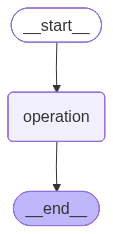

In [5]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
answer=app.invoke({"name":"Bob","values":[2,4,7,10],"operation":"*","result":""})
print(answer["result"])

Hi Bob.Your result based on your operation * is 560
